In [2]:
'''if 'google.colab' in str(get_ipython()):
    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy
    from os import chdir as cd
    cd('/content/OptiCommPy/')
    ! pip install .'''

"if 'google.colab' in str(get_ipython()):\n    ! git clone -b main https://github.com/edsonportosilva/OptiCommPy\n    from os import chdir as cd\n    cd('/content/OptiCommPy/')\n    ! pip install ."

In [3]:
from tqdm.notebook import tqdm
import numpy as np
import cupy as cp;
import numpy.lib.stride_tricks
import cupy.lib.stride_tricks
from numpy.fft import fft, ifft, fftfreq
from  scipy.constants import c
import matplotlib.pyplot as plt
import time

from optic.comm.modulation import modulateGray, grayMapping
from optic.dsp.core import pnorm, upsample, firFilter, pulseShape, signalPower, phaseNoise, decimate, symbolSync, finddelay
from optic.dsp.equalization import edc, mimoAdaptEqualizer
from optic.models.devices import iqm, coherentReceiver, pdmCoherentReceiver, basicLaserModel, mzm, edfa
from optic.models.channels import linearFiberChannel, awgn
from optic.utils import parameters
from optic.comm.metrics import fastBERcalc
from optic.plot import pconst, eyediagram, plotPSD
from optic.models.tx import simpleWDMTx
from optic.dsp.carrierRecovery import cpr

c:\GitHub\PIBITI\Marcos_PIBITI\Lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [4]:
def create_windows(x, paramEq):
    """
    xp = np ou xp dependendo da biblioteca usada (cupy ou numpy)
    Cria janelas temporais para polarização X e Y (coluna 0 e coluna 1), organizadas do tap mais antigo → tap mais novo.
    Essas matrizes são usadas posteriormente pelo equalizador adaptativo.

    Parametros
    ----------
    x : xp.ndarray - Sinal recebido, no formato [N_amostras x 2], onde a coluna 0 = polarização X, coluna 1 = polarização Y.
    paramEq : parameters - Estrutura de parâmetros que contém o número de taps (paramEq.nTaps).

    Retorno
    -------
      - xV (xp.ndarray): matriz [N x nTaps] com janelas temporais da polarização X (coluna 0).
      - xH (xp.ndarray): matriz [N x nTaps] com janelas temporais da polarização Y (coluna 1).
    """
    # Decisão entre numpy e cupy para a biblioteca correta
    xp = paramEq.xp
    as_strided = xp.lib.stride_tricks.as_strided

    N = x.shape[0] - paramEq.nTaps + 1
    shape = (N, paramEq.nTaps)
    x0 = xp.ascontiguousarray(x[:, 0])                                          # Colocando x[:, 0] como sinal contíguos
    x1 = xp.ascontiguousarray(x[:, 1])                                          # Colocando x[:, 1] como sinal contíguos

    stridesx = x0.itemsize
    xV_ = as_strided(x0, shape=shape, strides=(stridesx,stridesx))
    xV = xV_[:, ::-1]                                                           # Polarização X é a coluna 0

    stridesy = x1.itemsize
    xH_ = as_strided(x1, shape=shape, strides=(stridesy,stridesy))
    xH = xH_[:, ::-1]                                                           # Polarização Y é a coluna 1

    return xV, xH

In [5]:
def ddlmsUp(x, constSymb, nModes, paramEq):
    """
    Equalizador DD-LMS para um sistema MIMO 2x2.
    Implementação amostra-por-amostra com lógica de atualização corrigida.
    Parameters
    ----------
      x : xp.array - Sinal de entrada após o canal (polarizações X e Y nas colunas 0 e 1).
      constSymb : xp.array - Conjunto de símbolos da constelação (ex: QPSK, 16QAM) para decisões bruscas.
      nModes : int - Número de modos/polarizações (tipicamente 2).
      paramEq : parameters - Estrutura contendo parâmetros do equalizador, incluindo:
        - nTaps : número de coeficientes do filtro FIR por ramo.
        - mu : passo de atualização do LMS.
        - progBar : habilita/desabilita barra de progresso.

    Returns
    -------
      - y (xp.array, shape = [N, nModes]): saída estimada do equalizador para cada modo.
      - e (xp.array, shape = [N, nModes]): erro de decisão (diferença entre símbolo decidido e saída).
      - w (xp.array, shape = [nTaps, nModes**2]): matriz de coeficientes do equalizador MIMO 2x2.
      Cada coluna corresponde a um dos quatro ramos do equalizador:
            w[:,0] → w_xx  (entrada X → saída X)
            w[:,1] → w_xy  (entrada Y → saída X)
            w[:,2] → w_yx  (entrada X → saída Y)
            w[:,3] → w_yy  (entrada Y → saída Y)
    """

    # Decisão entre numpy e cupy para a biblioteca correta
    xp = paramEq.xp

    # Parâmetros para o processamento em blocos
    blockSize = paramEq.blockSize
    N = x.shape[0] - paramEq.nTaps + 1
    nBlocks = N // blockSize

    if N <= 0:
      raise ValueError("Sinal curto demais para nTaps")

    # Obtém o atraso da filtragem FIR
    delay = (paramEq.nTaps - 1) // 2

    # --- Pré-alocação de Memória ---
    y = xp.zeros((len(x), nModes), dtype='complex')
    e = xp.zeros((len(x), nModes), dtype='complex')
    w = xp.zeros((paramEq.nTaps, nModes**2), dtype='complex')

    # single spike initialization
    w[delay, 0] = 1                                                             # Filtro principal w_xx (para o Mode 0)
    w[delay, 3] = 1                                                             # Filtro principal w_yy (para o Mode 1)

    for i in tqdm(range(nBlocks), disable=not(paramEq.progBar)):

        n = i * blockSize
        n_delay = delay + n + blockSize
        x_ = x[n : n + blockSize + paramEq.nTaps - 1, :]

        # cria janelas temporais para polarização X e Y (coluna 0 e coluna 1)
        xV, xH = create_windows(x_, paramEq)

        # calcula a saída do equalizador 2x2
        y[delay + n : n_delay, 0] = xV @ w[:, 0] + xH @ w[:, 1]
        y[delay + n : n_delay, 1] = xV @ w[:, 2] + xH @ w[:, 3]

        y0 = y[delay + n : n_delay, 0]
        y1 = y[delay + n : n_delay, 1]

        # decisão brusca
        d0 = constSymb[xp.argmin(xp.abs(y0[:, None] - constSymb), axis = 1)]
        d1 = constSymb[xp.argmin(xp.abs(y1[:, None] - constSymb), axis = 1)]

        e[delay + n : n_delay, 0] = d0 - y[delay + n : n_delay, 0]
        e[delay + n : n_delay, 1] = d1 - y[delay + n : n_delay, 1]

        # atualiza os coeficientes do filtro
        w[:,0] += paramEq.mu[1] * (xV.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xx = w[:, 0]
        w[:,2] += paramEq.mu[1] * (xV.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yx = w[:, 2]
        w[:,1] += paramEq.mu[1] * (xH.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xy = w[:, 1]
        w[:,3] += paramEq.mu[1] * (xH.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yy = w[:, 3]

    return y, e, w

In [6]:
def rdeUp(x, constSymb, nModes, paramEq, y=None, e=None, w=None, preConv=False):
    """
    Equalizador RDE (Radius-Directed Equalization) para um sistema MIMO 2x2.
    Implementação em blocos com lógica de atualização corrigida.

    Parameters
    ----------
    x : xp.array - Sinal de entrada após o canal (polarizações X e Y nas colunas 0 e 1).
    constSymb : xp.array - Conjunto de símbolos da constelação (ex: 16QAM) para obter os raios ideais.
    nModes : int - Número de modos/polarizações (tipicamente 2).
    paramEq : parameters - Estrutura contendo parâmetros do equalizador, incluindo:
        - nTaps : número de coeficientes do filtro FIR por ramo.
        - mu : passo de atualização do RDE.
        - N1 : iteração para o "kick" de ortogonalidade.
        - progBar : habilita/desabilita barra de progresso.
    y : xp.array, opcional - Array de saída pré-alocado (usado no modo preConv).
    e : xp.array, opcional - Array de erro pré-alocado (usado no modo preConv).
    w : xp.array, opcional - Matriz de pesos pré-convergidos do CMA (usado no modo preConv).
    preConv : bool, opcional - Flag que indica se a função está sendo chamada após uma pré-convergência CMA.

    Returns
    -------
    tuple
        - y (xp.array, shape = [N, nModes]): saída estimada do equalizador para cada modo.
        - e (xp.array, shape = [N, nModes]): erro de decisão do RDE.
        - w (xp.array, shape = [nTaps, nModes**2]): matriz de coeficientes do equalizador MIMO 2x2.
          Cada coluna corresponde a um dos quatro ramos do equalizador:
                w[:,0] → w_xx  (entrada X → saída X)
                w[:,1] → w_xy  (entrada Y → saída X)
                w[:,2] → w_yx  (entrada X → saída Y)
                w[:,3] → w_yy  (entrada Y → saída Y)

    Referências
    -----------
    [1] Digital Coherent Optical Systems, Architecture and Algorithms
    """

    # Decisão entre numpy e cupy para a biblioteca correta
    xp = paramEq.xp

    # Parâmetros para o processamento em blocos
    blockSize = paramEq.blockSize
    N = x.shape[0] - paramEq.nTaps + 1
    nBlocks = N // blockSize

    # Obtém o atraso da filtragem FIR
    delay = (paramEq.nTaps - 1) // 2

    # obtem os raios da constelação M-QAM
    Rrde = xp.unique(xp.abs(constSymb))

    if preConv == False:

        paramEq.N2 = 0

        y = xp.zeros((len(x), nModes), dtype='complex')
        e = xp.zeros((len(x), nModes), dtype='complex')
        w = xp.zeros((paramEq.nTaps, nModes**2), dtype='complex')

        # single spike initialization
        w[delay, 0] = 1                                                             # Filtro principal w_xx (para o Mode 0)
        w[delay, 3] = 1                                                             # Filtro principal w_yy (para o Mode 1)

    N1_block = paramEq.N1 // blockSize if paramEq.N1 > 0 else -1

    for i in tqdm(range(nBlocks), disable=not(paramEq.progBar)):

        n = i * blockSize
        n_delay = delay + n + blockSize
        x_ = x[n : n + blockSize + paramEq.nTaps - 1, :]

        # cria janelas temporais para polarização X e Y (coluna 0 e coluna 1)
        xV, xH = create_windows(x_, paramEq)

        # calcula a saída do equalizador 2x2
        y[delay + n : n_delay, 0] = xV @ w[:, 0] + xH @ w[:, 1]
        y[delay + n : n_delay, 1] = xV @ w[:, 2] + xH @ w[:, 3]

        y0 = xp.abs(y[delay + n : n_delay, 0])
        y1 = xp.abs(y[delay + n : n_delay, 1])

        R1 = xp.argmin(xp.abs(Rrde - y0[:, None]), axis = 1)
        R2 = xp.argmin(xp.abs(Rrde - y1[:, None]), axis = 1)

        # calcula e atualiza erro para cada modo de polarização
        e[delay + n : n_delay, 0] = y[delay + n : n_delay, 0] * (Rrde[R1]**2 - y0**2)
        e[delay + n : n_delay, 1] = y[delay + n : n_delay, 1] * (Rrde[R2]**2 - y1**2)

        # atualiza os coeficientes do filtro
        w[:,0] += paramEq.mu[0] * (xV.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xx = w[:, 0]
        w[:,2] += paramEq.mu[0] * (xV.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yx = w[:, 2]
        w[:,1] += paramEq.mu[0] * (xH.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xy = w[:, 1]
        w[:,3] += paramEq.mu[0] * (xH.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yy = w[:, 3]

        if i == N1_block:
            # Defina a polarização Y como ortogonal a X para evitar
            # a convergência para a mesma polarização (evitar a singularidade CMA)
            w[:,3] =  xp.conj(w[:,0][::-1])
            w[:,2] = -xp.conj(w[:,1][::-1])

    return y, e, w

In [7]:
def cmaUp(x, constSymb, nModes, paramEq, preConv=False):
    """
    Equalizador CMA (Constant-Modulus Algorithm) para um sistema MIMO 2x2.

    Esta função implementa o algoritmo CMA usando uma abordagem de
    processamento em blocos para alta performance em GPU. Ela é projetada
    para realizar a convergência cega inicial, separando as polarizações
    e compensando o deslocamento de frequência.

    Parameters
    ----------
    x : xp.array - Sinal de entrada após o canal (polarizações X e Y nas colunas 0 e 1).
    constSymb : xp.array - Conjunto de símbolos da constelação (ex: 16QAM) para obter os raios ideais.
    nModes : int - Número de modos/polarizações (tipicamente 2).
    paramEq : parameters - Estrutura contendo parâmetros do equalizador, incluindo:
        - nTaps : número de coeficientes do filtro FIR por ramo.
        - mu : passo de atualização do RDE.
        - N1 : iteração para aplicar o "kick" de ortogonalidade.
        - N2 : iteração para parar a fase de pré-convergência do CMA.
        - progBar : booleano para habilitar/desabilitar a barra de progresso.
    preConv : bool, opcional - Flag que ativa o modo de pré-convergência. Se True, o loop para na iteração N2. O padrão é False.

    Returns
    -------
      - y (xp.array, shape = [N, nModes]): saída estimada do equalizador para cada modo.
      - e (xp.array, shape = [N, nModes]): erro de decisão (diferença entre símbolo decidido e saída).
      - w (xp.array, shape = [nTaps, nModes**2]): matriz de coeficientes do equalizador MIMO 2x2.
      Cada coluna corresponde a um dos quatro ramos do equalizador:
            w[:,0] → w_xx  (entrada X → saída X)
            w[:,1] → w_xy  (entrada Y → saída X)
            w[:,2] → w_yx  (entrada X → saída Y)
            w[:,3] → w_yy  (entrada Y → saída Y)

    Referências
    -----------
    [1] Digital Coherent Optical Systems, Architecture and Algorithms
    """

    # Decisão entre numpy e cupy para a biblioteca correta
    xp = paramEq.xp

    # Parâmetros para o processamento em blocos
    blockSize = paramEq.blockSize
    N = x.shape[0] - paramEq.nTaps + 1
    blocks_default = N // blockSize

    if N <= 0:
      raise ValueError("Sinal curto demais para nTaps")

    # Obtém o atraso da filtragem FIR
    delay = (paramEq.nTaps - 1) // 2

    y = xp.zeros((len(x), nModes),  dtype='complex')
    e = xp.zeros((len(x), nModes),  dtype='complex')
    w = xp.zeros((paramEq.nTaps, nModes**2),  dtype='complex')

    # single spike initialization
    w[delay, 0] = 1                                                             # Filtro principal w_xx (para o Mode 0)
    w[delay, 3] = 1                                                             # Filtro principal w_yy (para o Mode 1)

    # constante relacionada às características da modulação para o algoritmo CMA
    R = xp.mean(xp.abs(constSymb)**4) / xp.mean(xp.abs(constSymb)**2)

    N1_block = paramEq.N1 // blockSize if paramEq.N1 > 0 else -1
    nBlocks = paramEq.N2 // blockSize if preConv else blocks_default

    for i in tqdm(range(nBlocks), disable=not(paramEq.progBar)):

        n = i * blockSize
        n_delay = delay + n + blockSize
        x_ = x[n : n + blockSize + paramEq.nTaps - 1, :]

        # cria janelas temporais para polarização X e Y (coluna 0 e coluna 1)
        xV, xH = create_windows(x_, paramEq)

        # calcula a saída do equalizador 2x2
        y[delay + n : n_delay, 0] = xV @ w[:, 0] + xH @ w[:, 1]
        y[delay + n : n_delay, 1] = xV @ w[:, 2] + xH @ w[:, 3]

        # calcula e atualiza erro para cada modo de polarização
        e[delay + n : n_delay, 0] = y[delay + n : n_delay, 0] * (R - xp.abs(y[delay + n : n_delay, 0])**2)
        e[delay + n : n_delay, 1] = y[delay + n : n_delay, 1] * (R - xp.abs(y[delay + n : n_delay, 1])**2)

        # atualiza os coeficientes do filtro
        w[:,0] += paramEq.mu[0] * (xV.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xx = w[:, 0]
        w[:,2] += paramEq.mu[0] * (xV.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yx = w[:, 2]
        w[:,1] += paramEq.mu[0] * (xH.conj().T @ (e[delay + n : n_delay, 0])) / blockSize    # w_xy = w[:, 1]
        w[:,3] += paramEq.mu[0] * (xH.conj().T @ (e[delay + n : n_delay, 1])) / blockSize    # w_yy = w[:, 3]

        # Ortogonalização CMA apenas uma vez quando N1 for atingido
        if i == N1_block:
            w[:,3] =  xp.conj(w[:,0][::-1])
            w[:,2] = -xp.conj(w[:,1][::-1])

    if preConv:
        w_ = xp.max(xp.abs(w))
        w = w/w_ if w_ > 1e-6 else w
        y, e, w = rdeUp(x, constSymb, nModes, paramEq, y, e, w, preConv=True)

    return y, e, w

In [8]:
def mimoAdaptEq(x, paramEq):
    """
    Equalizador adaptativo MIMO 2x2

    Returns
    -------
    tuple
        - y (np.array): estimativa dos símbolos.
        - e (np.array): erro associado a cada modo de polarização.
        - w (np.array): matriz de coeficientes.

    Raises
    ------
    ValueError
        Caso o sinal não possua duas polarizações.

    ValueError
        Caso o algoritmo seja especificado incorretamente.
    """

    if x.shape[1] != 2:
        raise ValueError("O sinal deve conter duas polarizações")

    nModes = x.shape[1]

    # obtem os símbolos da constelação
    constSymb = grayMapping(paramEq.M, paramEq.constType)
    # normaliza os símbolos da constelação
    constSymb = pnorm(constSymb)
    
    if isinstance(x, cp.ndarray):
      constSymb = cp.asarray(constSymb)
      paramEq.xp = cp
    elif isinstance(x, np.ndarray):
      paramEq.xp = np

    if paramEq.alg == 'cma':
        y, e, w = cmaUp(x, constSymb, nModes, paramEq)
    elif paramEq.alg == 'rde':
        y, e, w = rdeUp(x, constSymb, nModes, paramEq)
    elif paramEq.alg == 'cma-to-rde':
        y, e, w = cmaUp(x, constSymb, nModes, paramEq, preConv=True)
    elif paramEq.alg == 'dd-lms':
        y, e, w = ddlmsUp(x, constSymb, nModes, paramEq)
    else:
        raise ValueError("Algoritmo de equalização especificado incorretamente.")

    return y, e, w

In [9]:
    ############## Canal Óptico ##############
def canal_optico(sigWDM_Tx, paramEDFA, paramTx):

  sigCh       = edfa(sigWDM_Tx, paramEDFA)                                      # modelo linear do EDFA

  # # deteriorates the signal-to-noise ratio before the fiber
  SNR         = 13
  sigAWGN     = awgn(sigWDM_Tx, SNR, Fs, paramTx.Rs)

  # simulate linear signal propagation
  sigCh       = linearFiberChannel(sigWDM_Tx, paramFiber)

  return sigCh

In [10]:
    ############## Receptor Óptico (PMD)##############
def receptor_optico(sigCh, paramTx, paramPD):

  # parameters
  chIndex     = 0  # index of the channel to be demodulated

  Fc          = paramTx.Fc
  Ts          = 1/Fs
  freqGrid    = paramTx.wdmFreqGrid
  π           = np.pi
  t           = np.arange(0, len(sigCh))*Ts

  symbTx      = symbTx_[:,:,chIndex]

  # local oscillator (LO) parameters:
  FO      = 150e6                                                               # deslocamento de frequência
  Δf_lo   = freqGrid[chIndex]+FO                                                # redução do canal a ser demodulado
  paramLO.Ns = len(sigCh)

  sigLO = basicLaserModel(paramLO)
  sigLO = sigLO*np.exp(1j*2*π*Δf_lo*t)                                          # adiciona deslocamento de frequência

  # polarization multiplexed coherent optical received
  θsig        = π/3 # polarization rotation angle
  sigRx       = pdmCoherentReceiver(sigCh, sigLO, θsig, paramPD)

  return sigRx

In [11]:
    ############## Filtro Casado e Compensação de CD ##############
def filtro_casado_cd(sigRx, paramTx, paramEDC):

  # Matched filtering
  paramPulse              = parameters()
  paramPulse.pulseType    = paramTx.pulseType
  paramPulse.SpS          = paramTx.SpS
  paramPulse.nFilterTaps  = paramTx.nFilterTaps
  paramPulse.pulseRollOff = paramTx.pulseRollOff

  pulse                   = pulseShape(paramPulse)

  pulse                   = pnorm(pulse)
  pulse                   = cp.asarray(pulse)
  sigRx                   = cp.asarray(sigRx)

  sigRx                   = firFilter(pulse, sigRx)
  sigRx                   = sigRx.get()

  sigRx                   = edc(sigRx, paramEDC)

  # decimate to one sample per symbol
  paramDec                = parameters()
  paramDec.SpSin          = paramTx.SpS
  paramDec.SpSout         = 1
  sigRx                   = decimate(sigRx, paramDec)

  x                       = pnorm(sigRx)
  x                       = cp.asarray(x)

  return x

In [12]:
    ############## Equalizadores ##############
def equalizador(x, paramTx, Nsymb):

  paramEq               = parameters()
  if (Nsymb == 7e3):
   paramEq.nTaps       = 3
   paramEq.mu          = [5e-1, 1e-2]
   paramEq.N1          = 500
   paramEq.N2          = 3000
   paramEq.blockSize   = 2**6

  elif (Nsymb == 2e4):
   paramEq.nTaps       = 10
   paramEq.mu          = [7e-1, 7e-2]
   paramEq.N1          = 4000
   paramEq.N2          = 15000
   paramEq.blockSize   = 2**9

  elif (Nsymb == 7e4):
   paramEq.nTaps       = 15
   paramEq.mu          = [7e-1, 7e-2]
   paramEq.N1          = 7000
   paramEq.N2          = 20000
   paramEq.blockSize   = 2**10

  elif (Nsymb == 3e5):
   paramEq.nTaps       = 15
   paramEq.mu          = [9e-1, 9e-2]
   paramEq.N1          = 10000
   paramEq.N2          = 25000
   paramEq.blockSize   = 2**11

  elif (Nsymb == 1e6):
   paramEq.nTaps       = 15
   paramEq.mu          = [9e-1, 9e-2]
   paramEq.N1          = 15000
   paramEq.N2          = 30000
   paramEq.blockSize   = 2**11

  else:
   print('Número de símbolos não suportado')
   breakpoint()

  paramEq.M             = paramTx.M
  paramEq.constType     = paramTx.constType
  paramEq.alg           = 'cma-to-rde'
  paramEq.progBar       = True

  t_start1              = time.perf_counter()
  y_EQ                  = mimoAdaptEq(x.get(), paramEq)
  t_end1                = time.perf_counter()
  timeEqCPU             = t_end1 - t_start1

  cp.cuda.Stream.null.synchronize()
  t_start2              = time.perf_counter()
  y_EQ_gpu              = mimoAdaptEq(x, paramEq)
  cp.cuda.Stream.null.synchronize()
  t_end2                = time.perf_counter()
  timeEqGPU             = t_end2 - t_start2

  yEQ                   = y_EQ[0]

  # Parametros da Portadora de Fase
  paramCPR              = parameters()
  paramCPR.alg          = 'bps'
  paramCPR.M            = paramTx.M
  paramCPR.N            = 75
  paramCPR.B            = 64

  y_CPR                 = cpr(yEQ, paramCPR, symbTx_)

  # Equalizador Adaptativo
  paramEq.alg           = 'dd-lms'
  y_CPR_gpu             = cp.asarray(y_CPR)

  t_start3              = time.perf_counter()
  y_LMS, e, _           = mimoAdaptEq(y_CPR, paramEq)
  t_end3                = time.perf_counter()
  timeEqAdCPU           = t_end3 - t_start3

  cp.cuda.Stream.null.synchronize()
  t_start4              = time.perf_counter()
  y_LMS_gpu, e, _       = mimoAdaptEq(y_CPR_gpu, paramEq)
  cp.cuda.Stream.null.synchronize()
  t_end4                = time.perf_counter()
  timeEqAdGPU           = t_end4 - t_start4

  y_CPR_LMS             = cpr(y_LMS, paramCPR)

  return y_CPR, y_CPR_LMS, timeEqCPU, timeEqGPU, timeEqAdCPU, timeEqAdGPU

In [13]:
    ############## Resultados ##############
def resultados(y_CPR_LMS, paramTx, symbTx_, Nsymb):

  discard = int(0.1 * y_CPR_LMS.shape[0])
  d = pnorm(symbTx_)
  ind = np.arange(discard, d.shape[0]-discard)
  # Remove a 3ª dimensão
  rx = y_CPR_LMS[ind,:]
  tx = d[ind,:]

  if rx.ndim == 3 and rx.shape[2] == 1:
        rx = rx[:, :, 0]
  if tx.ndim == 3 and tx.shape[2] == 1:
        tx = tx[:, :, 0]

  delay = finddelay(rx[:,1], tx[:,1])

  # Alinhar com symbolSync
  tx_sync = symbolSync(rx, tx, SpS=1, mode='amp')

  # Truncar sinais para comprimento comum
  min_len = min(rx.shape[0], tx_sync.shape[0])
  rx = rx[:min_len]
  tx = tx_sync[:min_len]

  delay = finddelay(rx[:,0], tx[:,0])

  rx = pnorm(rx)
  tx = pnorm(tx)
  BER, SER, SNR = fastBERcalc(rx, tx, paramTx.M, paramTx.constType)

  print('##########   Resultados da simulação - %s Nsymb   ##########\n'%Nsymb)
  print('      pol.X      pol.Y      ')
  print(' SER: %.2e,  %.2e'%(SER[0], SER[1]))
  print(' BER: %.2e,  %.2e'%(BER[0], BER[1]))
  print(' SNR: %.2f dB,  %.2f dB\n'%(SNR[0], SNR[1]))

  return tx, rx

In [ ]:
t_start = time.perf_counter()
##################### TRANSMISSOR #####################

# Transmitter parameters:
paramTx                 = parameters()
paramTx.M               = 64                                                    # ordem do formato de modulação
paramTx.constType       = 'qam'                                                 # esquema de modulação
paramTx.seed            = 42                                                    # semente - torna saidas no mesmo padrao
paramTx.Rs              = 32e9                                                  # taxa de símbolo [baud]
paramTx.SpS             = 16                                                    # amostras por símbolo
paramTx.pulseType       = 'rrc'                                                 # filtro de modelagem de pulso
paramTx.nFilterTaps     = 4096                                                  # número de coeficientes de filtro de modelagem de pulso
paramTx.pulseRollOff    = 0.01                                                  # Eliminação do RRC
paramTx.powerPerChannel = -2                                                    # potência por canal WDM [dBm]
paramTx.nChannels       = 1                                                     # número de canais WDM
paramTx.Fc              = 193.1e12                                              # frequência óptica central do espectro WDM
paramTx.laserLinewidth  = 100e3                                                 # largura de linha do laser em Hz
paramTx.wdmGridSpacing  = 37.5e9                                                # Espaçamento de grade WDM
paramTx.nPolModes       = 2                                                     # número de modos de sinal [2 para sinais multiplexados por polarização]

Fs                      = paramTx.Rs * paramTx.SpS                              # taxa de amostragem de simulação

## fiber parameters:
paramFiber              = parameters()
paramFiber.L            = 300                                                   # comprimento do enlace [km]
paramFiber.alpha        = 0.2                                                   # coeficiente de perdas [dB/Km]
paramFiber.D            = 17                                                    # parâmetro de dispersão [ps/nm/km]
paramFiber.Fs           = Fs                                                    # Frequência de amostragem do sinal [amostras/segundo]
paramFiber.Fc           = paramTx.Fc                                            # Frequência central do sinal [Hz]

# EDFA parameters:
paramEDFA               = parameters()
paramEDFA.G             = paramFiber.alpha * paramFiber.L                       # Ganho para compensar
paramEDFA.Fs            = Fs
paramEDFA.NF            = 7
paramEDFA.Fc            = paramTx.Fc

# generate CW laser LO field
paramLO                 = parameters()
paramLO.P               = 10                                                    # power in dBm
paramLO.lw              = 100e3                                                 # laser linewidth
paramLO.RIN_var         = 0                                                     # variancia do ruido
paramLO.Fs              = Fs

# Define os parâmetros do receptor coerente
paramPD                 = parameters()
paramPD.B               = paramTx.Rs
paramPD.Fs              = Fs
paramPD.ideal           = True

# CD compensation
paramEDC                = parameters()
paramEDC.L              = paramFiber.L
paramEDC.D              = paramFiber.D
paramEDC.Fc             = paramTx.Fc
paramEDC.Fs             = Fs

numberOfSymbols         = np.array([7e3, 2e4, 7e4, 3e5, 1e6])

timeEqCPU = np.zeros(len(numberOfSymbols))
timeEqGPU = np.zeros(len(numberOfSymbols))
timeEqAdCPU = np.zeros(len(numberOfSymbols))
timeEqAdGPU = np.zeros(len(numberOfSymbols))

for idx, Nsymb in enumerate(tqdm(numberOfSymbols)):

    paramTx.nBits       = int(np.log2(paramTx.M)*Nsymb)                         # total number of bits per polarization

    # generate WDM signal
    sigWDM_Tx, symbTx_, paramTx = simpleWDMTx(paramTx)

    sigCh               = canal_optico(sigWDM_Tx, paramEDFA, paramTx)           # função retorna o campo óptico complexo depois de passar pelo EDFA → AWGN → fibra linear.
    sigRx               = receptor_optico(sigCh, paramTx, paramPD)              # função retorna o sinal elétrico após o fotodetector balanceado após sigCh → LO → mixer → PD → sigRx
    x                   = filtro_casado_cd(sigRx, paramTx, paramEDC)            # função reorna o sinal após o filtro casado, a compensação de dispersão e decimação
    y_CPR, y_CPR_LMS, timeEqCPU_, timeEqGPU_, timeEqAdCPU_, timeEqAdGPU_        = equalizador(x, paramTx, Nsymb)         # função retorna os sinais equalizados apos o CMA → RDE → DD-LMS
    # Armazenando os tempos calculados em cada repetição

    timeEqCPU[idx]      = timeEqCPU_
    timeEqGPU[idx]      = timeEqGPU_
    timeEqAdCPU[idx]    = timeEqAdCPU_
    timeEqAdGPU[idx]    = timeEqAdGPU_
    tx, rx = resultados(y_CPR_LMS, paramTx, symbTx_, Nsymb)

np.savez_compressed(
    "tempo_execucao_colab.npz",
    numberOfSymbols=numberOfSymbols.astype(float),  # garante float
    timeEqCPU=timeEqCPU,
    timeEqGPU=timeEqGPU,
    timeEqAdCPU=timeEqAdCPU,
    timeEqAdGPU=timeEqAdGPU
)
print("Arquivo salvo: tempo_execucao_colab.npz")

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/109 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

...

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

  0%|          | 0/488 [00:00<?, ?it/s]

##########   Resultados da simulação - 1000000.0 Nsymb   ##########

      pol.X      pol.Y      
 SER: 1.25e-06,  6.25e-06
 BER: 2.08e-07,  1.04e-06
 SNR: 27.09 dB,  27.13 dB

Arquivo salvo: tempo_execucao_colab.npz


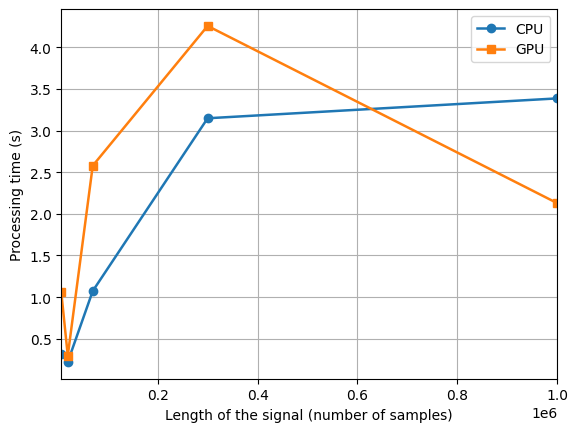

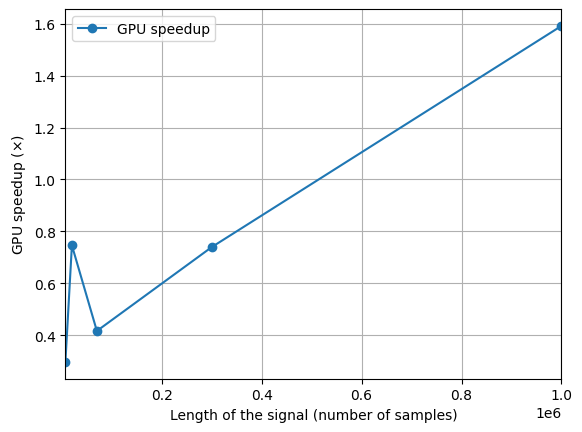

In [15]:
plt.plot(numberOfSymbols, timeEqCPU, '-o', linewidth=1.8, label='CPU')
plt.plot(numberOfSymbols, timeEqGPU, '-s', linewidth=1.8, label='GPU')
plt.xlabel('Length of the signal (number of samples)')
plt.ylabel('Processing time (s)')
plt.legend()
plt.grid()
plt.xlim(min(numberOfSymbols), max(numberOfSymbols));

plt.figure()
plt.plot(numberOfSymbols, timeEqCPU/timeEqGPU,'-o', label='GPU speedup')
plt.xlabel('Length of the signal (number of samples)')
plt.ylabel('GPU speedup ($\\times$)')
plt.legend()
plt.grid()
plt.xlim(min(numberOfSymbols), max(numberOfSymbols));

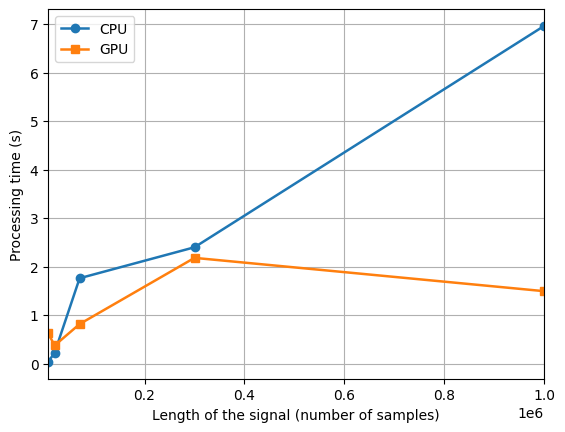

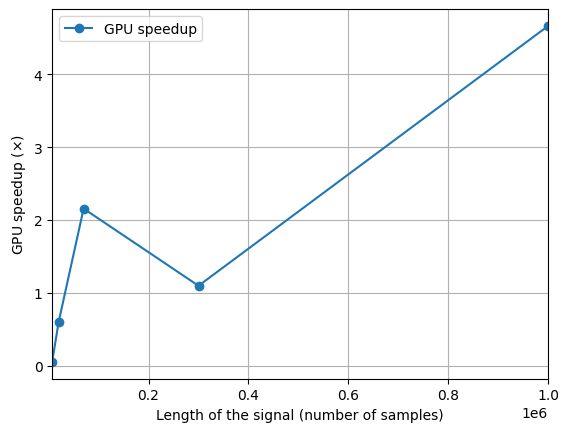

In [16]:
plt.plot(numberOfSymbols, timeEqAdCPU, '-o', linewidth=1.8, label='CPU')
plt.plot(numberOfSymbols, timeEqAdGPU, '-s', linewidth=1.8, label='GPU')
plt.xlabel('Length of the signal (number of samples)')
plt.ylabel('Processing time (s)')
plt.legend()
plt.grid()
plt.xlim(min(numberOfSymbols), max(numberOfSymbols));

plt.figure()
plt.plot(numberOfSymbols, timeEqAdCPU/timeEqAdGPU,'-o', label='GPU speedup')
plt.xlabel('Length of the signal (number of samples)')
plt.ylabel('GPU speedup ($\\times$)')
plt.legend()
plt.grid()
plt.xlim(min(numberOfSymbols), max(numberOfSymbols));

##########   Resultados da simulação - 1000000.0 Nsymb   ##########

      pol.X      pol.Y      
 SER: 1.25e-06,  6.25e-06
 BER: 2.08e-07,  1.04e-06
 SNR: 27.09 dB,  27.13 dB



c:\GitHub\PIBITI\Marcos_PIBITI\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\GitHub\PIBITI\Marcos_PIBITI\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


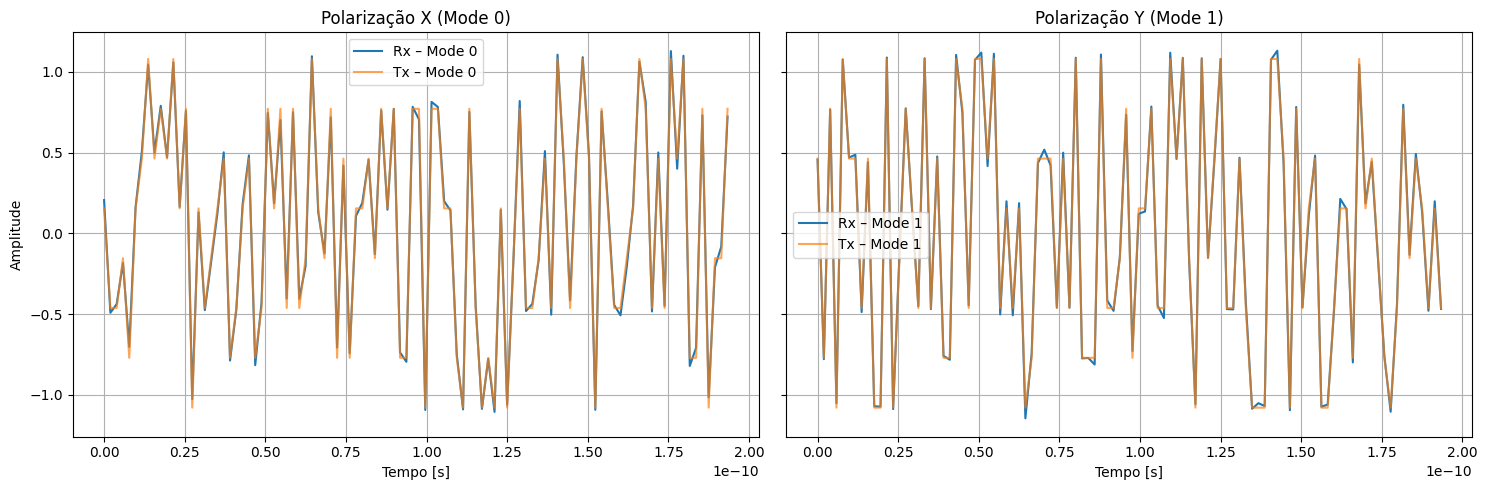

Tempo total = 849.87 s


In [ ]:
t = np.arange(100) / Fs

fig, axs = plt.subplots(1, 2, figsize=(15, 5), sharey=True);
# Modo X
axs[0].plot(t, rx[:100, 0], label="Rx – Mode 0")
axs[0].plot(t, tx[:100, 0], label="Tx – Mode 0", alpha=0.7)
axs[0].set_title("Polarização X (Mode 0)")
axs[0].set_xlabel("Tempo [s]")
axs[0].set_ylabel("Amplitude")
axs[0].legend()
axs[0].grid(True)

# Modo Y
axs[1].plot(t, rx[:100, 1], label="Rx – Mode 1")
axs[1].plot(t, tx[:100, 1], label="Tx – Mode 1", alpha=0.7)
axs[1].set_title("Polarização Y (Mode 1)")
axs[1].set_xlabel("Tempo [s]")
axs[1].legend()
axs[1].grid(True)

fig.tight_layout()
plt.show()
t_end = time.perf_counter()
elapsed = t_end - t_start
print(f"Tempo total = {elapsed:.2f} s")